# 子图

> 两种方式
*  将已编译的子图作为节点添加到父图

*  使用节点函数调用子图，并进行状态转换
    > 更加灵活，可自定义状态转换逻辑

>典型应用场景
* 多智能体RAG系统
    * 父图(Supervisor Agent): 关注最终RAG报告
    * 子图(ReAct Agent): 维护详细对话历史和工具调用记录


##  1.将已编译的子图作为节点添加到父图

In [6]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

import os
from dotenv import load_dotenv

load_dotenv()
print(f"测试环境变量: {os.getenv('OPENAI_API_KEY')}")


测试环境变量: sk-52338e5bc4704f45b2dbadc410b0daf8


### 定义子图1: 数据处理子图

数据处理子图构建完成
流程: START -> validate -> clean -> transform -> END


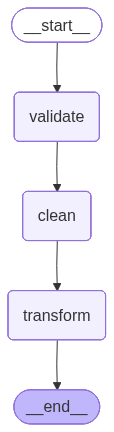

In [7]:
class DataProcessingState(TypedDict):
    input_data: str
    processed_data: str
    processing_steps: list

def validate_data(state: DataProcessingState):
    """数据验证节点
    检查输入数据是否为空, 并记录验证结果
    """
    input_data = state["input_data"]
    is_valid = len(input_data.strip()) > 0
    return {
        "processing_steps": [f"Validation: {'Passed' if is_valid else 'Failed'}"],
        "processed_data": input_data if is_valid else ""
    }

def clean_data(state: DataProcessingState):
    """数据清洗节点
    清洗数据, 移除空格和特殊字符
    """
    data = state["processed_data"]
    cleaned_data = data.strip().lower().replace(",", "")
    return {
        "processing_steps": [f"Cleaning: Removed whitespace and special chars"],
        "processed_data": cleaned_data
    }

def transform_data(state: DataProcessingState):
    """数据转换节点
    转换数据, 增加前缀 + 转换为大写
    """
    data = state["processed_data"]
    transformed_data = f"PROCESSED: {data.upper()}"
    return {
        "processing_steps": [f"Transform: Converted to uppercase with prefix"],
        "processed_data": transformed_data
    }

# 构建数据处理子图
data_processing_builder = StateGraph(DataProcessingState)
data_processing_builder.add_node("validate", validate_data)
data_processing_builder.add_node("clean", clean_data)  
data_processing_builder.add_node("transform", transform_data)

data_processing_builder.add_edge(START, "validate")
data_processing_builder.add_edge("validate", "clean")
data_processing_builder.add_edge("clean", "transform")
data_processing_builder.add_edge("transform", END)

# 编译数据处理子图
data_processing_subgraph = data_processing_builder.compile()

print("数据处理子图构建完成")
print("流程: START -> validate -> clean -> transform -> END")


try:
    display(Image(data_processing_subgraph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

### 定义子图2: 报告生成子图

报告生成子图构建完成
流程: START -> generate_title -> create_report -> END


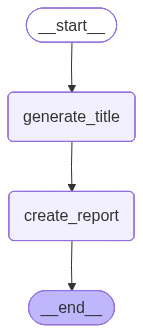

In [8]:
class ReportState(TypedDict):
    processed_data: str
    report_title: str
    final_report: str

def generate_title(state: ReportState):
    """生成报告标题
    标题生成规则：固定前缀 + 数据内容前20个字符"""
    processed_data = state["processed_data"]
    title = f"Data Analysis Report: {processed_data[:20]}..."
    return {"report_title": title}

def create_report(state: ReportState):
    """创建完整报告
    """
    title = state["report_title"]  
    data = state["processed_data"]
    report = f"""{title}
    Data Content: {data}
    Report Generated: Successfully processed data
    Status: Complete
    """
    return {"final_report": report}

# 构建报告生成子图  
report_builder = StateGraph(ReportState)
report_builder.add_node("generate_title", generate_title)
report_builder.add_node("create_report", create_report)

report_builder.add_edge(START, "generate_title")
report_builder.add_edge("generate_title", "create_report") 
report_builder.add_edge("create_report", END)

# 编译报告生成子图
report_subgraph = report_builder.compile()

print("报告生成子图构建完成")
print("流程: START -> generate_title -> create_report -> END")

try:
    display(Image(report_subgraph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

### 定义父图：整合两个子图

主工作流构建完成
流程: START -> data_processing(子图1) -> report_generation(子图2) -> END


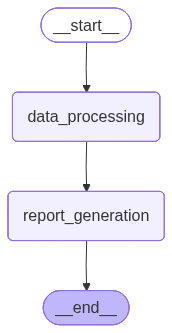

In [9]:
class MainWorkflowState(TypedDict):
    raw_input: str
    workflow_status: str
    final_output: str

def call_data_processing(state: MainWorkflowState):
    """调用数据处理子图的节点函数"""
    # 状态转换：父图状态 -> 子图状态
    subgraph_input = {
        "input_data": state["raw_input"],
        "processed_data": "",
        "processing_steps": []
    }
    
    # 调用数据处理子图
    subgraph_output = data_processing_subgraph.invoke(subgraph_input)
    
    # 状态转换：子图状态 -> 父图状态  
    return {
        "workflow_status": "Data processing completed",
        "final_output": subgraph_output["processed_data"]
    }

def call_report_generation(state: MainWorkflowState):
    """调用报告生成子图的节点函数"""
    # 状态转换：父图状态 -> 子图状态
    subgraph_input = {
        "processed_data": state["final_output"],
        "report_title": "",
        "final_report": ""
    }
    
    # 调用报告生成子图
    subgraph_output = report_subgraph.invoke(subgraph_input)
    
    # 状态转换：子图状态 -> 父图状态
    return {
        "workflow_status": "Report generation completed", 
        "final_output": subgraph_output["final_report"]
    }

# 构建主工作流父图
main_builder = StateGraph(MainWorkflowState)
main_builder.add_node("data_processing", call_data_processing)
main_builder.add_node("report_generation", call_report_generation)

main_builder.add_edge(START, "data_processing")
main_builder.add_edge("data_processing", "report_generation")  
main_builder.add_edge("report_generation", END)

# 编译主工作流
main_workflow = main_builder.compile()

print("主工作流构建完成")
print("流程: START -> data_processing(子图1) -> report_generation(子图2) -> END")


try:
    display(Image(main_workflow.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass




In [10]:
# ===== 测试子图模块化系统 =====
print("\n=== 测试子图模块化系统 ===")
test_input = "Hello, World! This is sample data for processing."

result = main_workflow.invoke({
    "raw_input": test_input,
    "workflow_status": "",
    "final_output": ""
})

print(f"\n输入数据: {test_input}")
print(f"工作流状态: {result['workflow_status']}")
print("\n最终报告:")
print(result["final_output"])


=== 测试子图模块化系统 ===

输入数据: Hello, World! This is sample data for processing.
工作流状态: Report generation completed

最终报告:
Data Analysis Report: PROCESSED: HELLO WOR...
    Data Content: PROCESSED: HELLO WORLD! THIS IS SAMPLE DATA FOR PROCESSING.
    Report Generated: Successfully processed data
    Status: Complete
    


## 2. 使用节点函数调用子图并进行状态转换

🏗️ 构建子图...
✅ 子图编译完成

🏗️ 构建父图...
✅ 父图构建完成！

📥 初始父图状态: {'my_key': '用户输入数据'}

🔧 父图节点1: 预处理 '用户输入数据'
🔄 调用子图节点: 接收父图状态 '父图预处理: 用户输入数据'
🔀 状态转换: 父图状态 -> 子图状态
   输入子图: {'my_child_key': '父图预处理: 用户输入数据'}
🔧 子图节点1: 处理输入 '父图预处理: 用户输入数据'
🔧 子图节点2: 进一步处理 '子图处理: 父图预处理: 用户输入数据'
📤 子图输出: {'my_child_key': '子图处理: 父图预处理: 用户输入数据 -> 完成处理'}
🔀 状态转换: 子图状态 -> 父图状态
   返回父图: {'my_key': '子图处理: 父图预处理: 用户输入数据 -> 完成处理'}
🔧 父图节点2: 后处理 '子图处理: 父图预处理: 用户输入数据 -> 完成处理'

📤 最终父图状态: {'my_key': '子图处理: 父图预处理: 用户输入数据 -> 完成处理 -> 父图完成'}


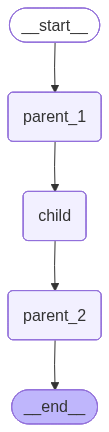

In [12]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

# 模拟子图 child_graph 的定义和编译（这里用简化版本）
class ChildState(TypedDict):
    my_child_key: str

def child_node_1(state: ChildState):
    print(f"🔧 子图节点1: 处理输入 '{state['my_child_key']}'")
    return {"my_child_key": f"子图处理: {state['my_child_key']}"}

def child_node_2(state: ChildState):
    print(f"🔧 子图节点2: 进一步处理 '{state['my_child_key']}'")
    return {"my_child_key": f"{state['my_child_key']} -> 完成处理"}

# 构建子图
print("🏗️ 构建子图...")
child_builder = StateGraph(ChildState)
child_builder.add_node("child_1", child_node_1)
child_builder.add_node("child_2", child_node_2)
child_builder.add_edge(START, "child_1")
child_builder.add_edge("child_1", "child_2")
child_builder.add_edge("child_2", END)

child_graph = child_builder.compile()
print("✅ 子图编译完成")

# 定义父图
class ParentState(TypedDict):  # 父图的状态结构体 
    my_key: str  # 父图状态键: my_key

def call_child_graph(state: ParentState) -> ParentState:  # 节点函数，输入输出状态类型都为 ParentState
    print(f"🔄 调用子图节点: 接收父图状态 '{state['my_key']}'")

    # 状态转换: 父图状态 -> 子图状态 (ParentState.my_key -> ChildState.my_child_key)
    child_graph_input = {"my_child_key": state["my_key"]}  # 将父图状态的 my_key 值，赋值给子图状态的 my_child_key 键
    print(f"🔀 状态转换: 父图状态 -> 子图状态")
    print(f"   输入子图: {child_graph_input}")

    # 调用子图
    child_graph_output = child_graph.invoke(child_graph_input)  # 调用子图 child_graph
    print(f"📤 子图输出: {child_graph_output}")

    # 状态转换: 子图状态 -> 父图状态 (ChildState.my_child_key -> ParentState.my_key)
    result = {"my_key": child_graph_output["my_child_key"]}  # 将子图输出状态的 my_child_key 值，赋值给父图状态的 my_key 键
    print(f"🔀 状态转换: 子图状态 -> 父图状态")
    print(f"   返回父图: {result}")

    return result

def parent_node_1(state: ParentState):
    print(f"🔧 父图节点1: 预处理 '{state['my_key']}'")
    return {"my_key": f"父图预处理: {state['my_key']}"}

def parent_node_2(state: ParentState):
    print(f"🔧 父图节点2: 后处理 '{state['my_key']}'")
    return {"my_key": f"{state['my_key']} -> 父图完成"}

print("\n🏗️ 构建父图...")
builder = StateGraph(ParentState)  # 创建父图 StateGraph，指定状态结构体为 
ParentState

# 父图的其他节点定义
builder.add_node("parent_1", parent_node_1)
builder.add_node("parent_2", parent_node_2)
builder.add_node("child", call_child_graph)  # 将节点函数 call_child_graph 作为节点添加到父图，节点名为 "child"

builder.add_edge(START, "parent_1")  # 父图节点 parent_1 -> 节点函数 call_child_graph (普通边)
builder.add_edge("parent_1", "child")
builder.add_edge("child", "parent_2")
builder.add_edge("parent_2", END)

graph = builder.compile()  # 编译父图
print("✅ 父图构建完成！")

# 测试运行
initial_state = {"my_key": "用户输入数据"}
print(f"\n📥 初始父图状态: {initial_state}")
print("\n" + "="*60)

result = graph.invoke(initial_state)

print("="*60)
print(f"\n📤 最终父图状态: {result}")

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass